# EDA — Nhận dạng chữ số viết tay

# 1. Tổng Quan Dữ Liệu & Kiểu Dữ Liệu
## 1.1 Dataset Size

**What:** Đếm ảnh trong tập Train.

**Why:** xác nhận quy mô dữ liệu dùng cho EDA mà không nhìn vào Test.

**How:** chỉ đọc PNG trong `Dataset/Split data/Figures/Train`; ảnh sai kích thước được ghi nhận thay vì đưa vào ma trận.

Train valid: 49,000 | Invalid: 0 | X_train: (49000, 28, 28)


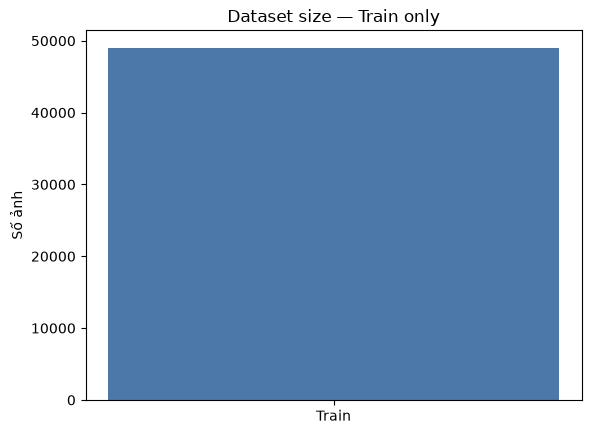

In [1]:
from pathlib import Path
from collections import Counter
from hashlib import sha1
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == "EDA" else Path.cwd()
TRAIN_DIR = ROOT / "Dataset" / "Split data" / "Figures" / "Train"
records, invalid = [], []
for p in sorted(TRAIN_DIR.glob("*.png")):
    try:
        with Image.open(p) as im:
            meta = (im.format, im.mode, im.size)
            a = np.asarray(im.convert("L"))
        if a.shape != (28, 28): raise ValueError(f"shape={a.shape}")
        records.append((p, int(p.name.split("_", 1)[0]), a, meta))
    except Exception as e: invalid.append((str(p), str(e)))
X_train = np.stack([r[2] for r in records]); y_train = np.array([r[1] for r in records])
paths = [r[0] for r in records]; counts = {"Train": len(X_train)}
print(f"Train valid: {len(X_train):,} | Invalid: {len(invalid):,} | X_train: {X_train.shape}")
plt.bar(counts.keys(), counts.values(), color="#4C78A8")
plt.title("Dataset size — Train only"); plt.ylabel("Số ảnh"); plt.show()

## 1.2 Image Format, Shape & Data Type

**What:** Kiểm tra định dạng, mode, shape và dtype.

**Why:** mô hình cần đầu vào đồng nhất.

**How:** tổng hợp metadata đọc từ từng ảnh và trực quan hóa các shape quan sát được.

Format: Counter({'PNG': 49000}) | Mode: Counter({'L': 49000}) | dtype: uint8 | pixel shape: (28, 28)


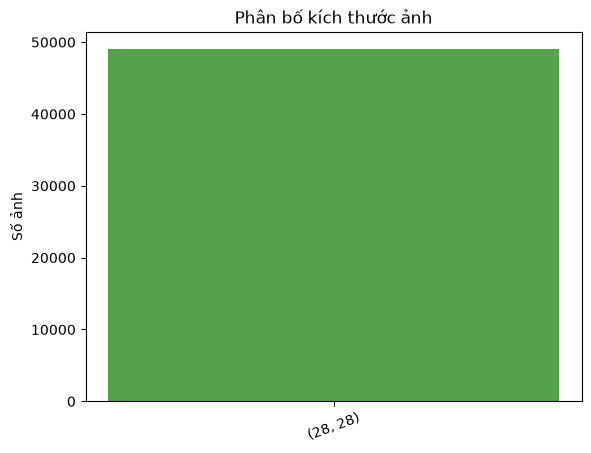

In [2]:
formats = Counter(r[3][0] for r in records); modes = Counter(r[3][1] for r in records)
sizes = Counter(str(r[3][2]) for r in records)
print("Format:", formats, "| Mode:", modes, "| dtype:", X_train.dtype, "| pixel shape:", X_train.shape[1:])
plt.bar(sizes.keys(), sizes.values(), color="#54A24B")
plt.title("Phân bố kích thước ảnh"); plt.ylabel("Số ảnh"); plt.xticks(rotation=20); plt.show()

## 1.3 Sample Images

**What:** Hiển thị một ảnh đại diện cho mỗi chữ số.

**Why:** xác nhận nhanh nhãn và nội dung ảnh.

**How:** lấy mẫu đầu tiên của từng lớp từ dữ liệu hợp lệ.

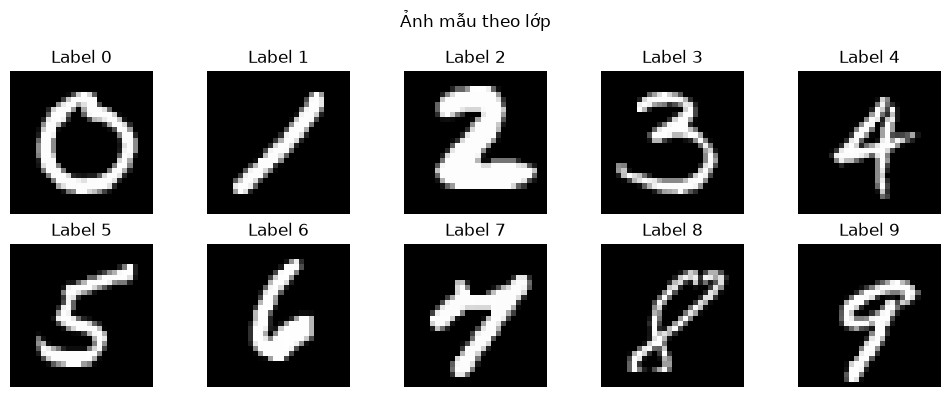

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    i = np.flatnonzero(y_train == digit)[0]
    ax.imshow(X_train[i], cmap="gray"); ax.set_title(f"Label {digit}"); ax.axis("off")
plt.suptitle("Ảnh mẫu theo lớp"); plt.tight_layout(); plt.show()

# 2. Thống Kê Tổng Hợp (Summary Statistics)
## 2.1 Numerical Features

**What:** Tính pixel range, mean, median, standard deviation, feature variance và zero-pixel ratio.

**Why:** nhận diện thang đo và độ thưa của ảnh.

**How:** thống kê trên ma trận pixel `uint8`; variance được tính theo từng vị trí pixel.

{'min': 0.0, 'max': 255.0, 'mean': 33.41, 'median': 0.0, 'std': 78.6828, 'mean_feature_var': 4376.0273, 'zero_ratio': 0.8085}


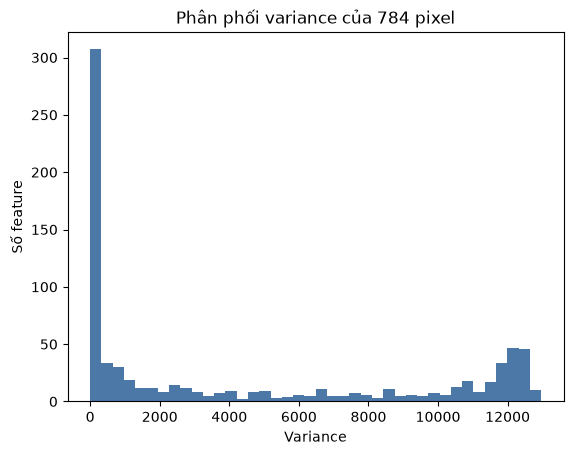

In [4]:
flat_train = X_train.reshape(len(X_train), -1); train_feature_var = flat_train.var(axis=0)
stats = {"min": flat_train.min(), "max": flat_train.max(), "mean": flat_train.mean(), "median": np.median(flat_train),
         "std": flat_train.std(), "mean_feature_var": train_feature_var.mean(), "zero_ratio": (flat_train == 0).mean()}
print({k: round(float(v), 4) for k, v in stats.items()})
plt.hist(train_feature_var, bins=40, color="#4C78A8")
plt.title("Phân phối variance của 784 pixel"); plt.xlabel("Variance"); plt.ylabel("Số feature"); plt.show()

## 2.2 Categorical Features

**What:** Đếm nhãn và tỷ lệ từng lớp.

**Why:** đánh giá cân bằng lớp.

**How:** tổng hợp `label` từ tên tệp và vẽ tỷ lệ phần trăm.

{0: {'count': 4832, 'percent': np.float64(9.86)}, 1: {'count': 5514, 'percent': np.float64(11.25)}, 2: {'count': 4893, 'percent': np.float64(9.99)}, 3: {'count': 4999, 'percent': np.float64(10.2)}, 4: {'count': 4777, 'percent': np.float64(9.75)}, 5: {'count': 4419, 'percent': np.float64(9.02)}, 6: {'count': 4813, 'percent': np.float64(9.82)}, 7: {'count': 5105, 'percent': np.float64(10.42)}, 8: {'count': 4777, 'percent': np.float64(9.75)}, 9: {'count': 4871, 'percent': np.float64(9.94)}}


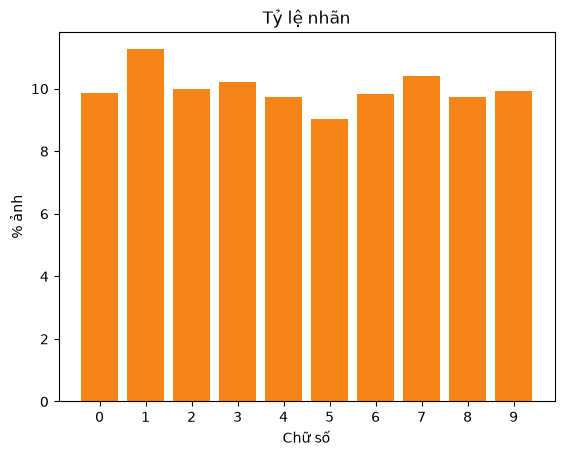

In [5]:
label_count = np.bincount(y_train, minlength=10); label_pct = label_count / len(y_train) * 100
print({i: {"count": int(label_count[i]), "percent": round(label_pct[i], 2)} for i in range(10)})
plt.bar(range(10), label_pct, color="#F58518")
plt.title("Tỷ lệ nhãn"); plt.xlabel("Chữ số"); plt.ylabel("% ảnh"); plt.xticks(range(10)); plt.show()

# 3. Phân Tích Đơn Biến & Phân Phối (Univariate Analysis & Distributions)
## 3.1 Pixel Intensity Distribution

**What:** Khảo sát phân phối cường độ pixel.

**Why:** quyết định nhu cầu chuẩn hóa và hiểu mức nền.

**How:** histogram trên toàn bộ pixel với miền 0–255.

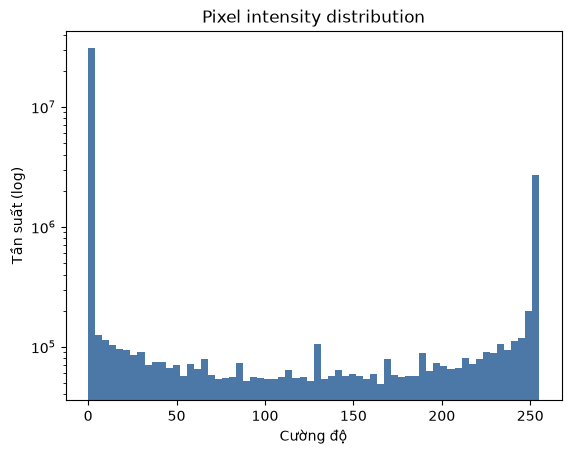

In [6]:
plt.hist(flat_train.ravel(), bins=64, range=(0, 255), color="#4C78A8", log=True)
plt.title("Pixel intensity distribution"); plt.xlabel("Cường độ"); plt.ylabel("Tần suất (log)"); plt.show()

## 3.2 Class Distribution

**What:** Phân tích phân phối chữ số trong tập Train.

**Why:** đánh giá cân bằng lớp trên dữ liệu được phép dùng để ra quyết định model.

**How:** đếm và trực quan hóa số ảnh của từng nhãn 0–9 trong Train.

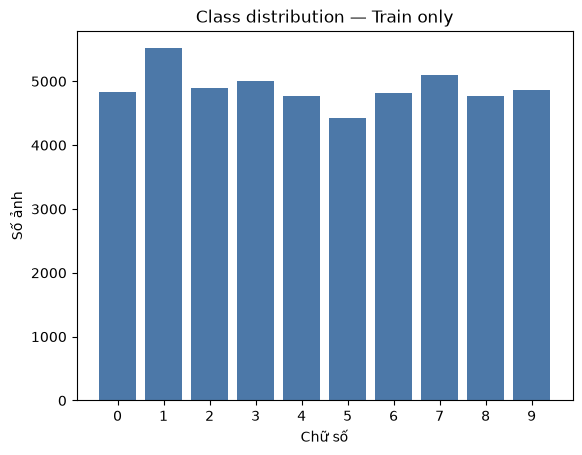

In [7]:
train_class_count = np.bincount(y_train, minlength=10)
plt.bar(range(10), train_class_count, color="#4C78A8")
plt.title("Class distribution — Train only"); plt.xlabel("Chữ số"); plt.ylabel("Số ảnh")
plt.xticks(range(10)); plt.show()

# 4. Phân Tích Song Biến & Tương Quan (Bivariate Analysis, Correlation & Patterns)
## 4.1 Numerical vs Numerical — Variance & Correlation

**What:** Phân tích 12 pixel có variance cao nhất trên Train; đây không phải 12 feature quan trọng nhất cho classification.

**Why:** khảo sát signal similarity và spatial redundancy mà không tạo ma trận 784×784.

**How:** chọn theo variance trên Train, bổ sung tọa độ `(row, col)` và tính Pearson correlation. Correlation cao chưa đủ để kết luận multicollinearity.

12 pixel có variance cao nhất: ['p378 (13,14)', 'p406 (14,14)', 'p627 (22,11)', 'p461 (16,13)', 'p462 (16,14)', 'p437 (15,17)', 'p628 (22,12)', 'p433 (15,13)', 'p434 (15,14)', 'p409 (14,17)', 'p184 (6,16)', 'p183 (6,15)']


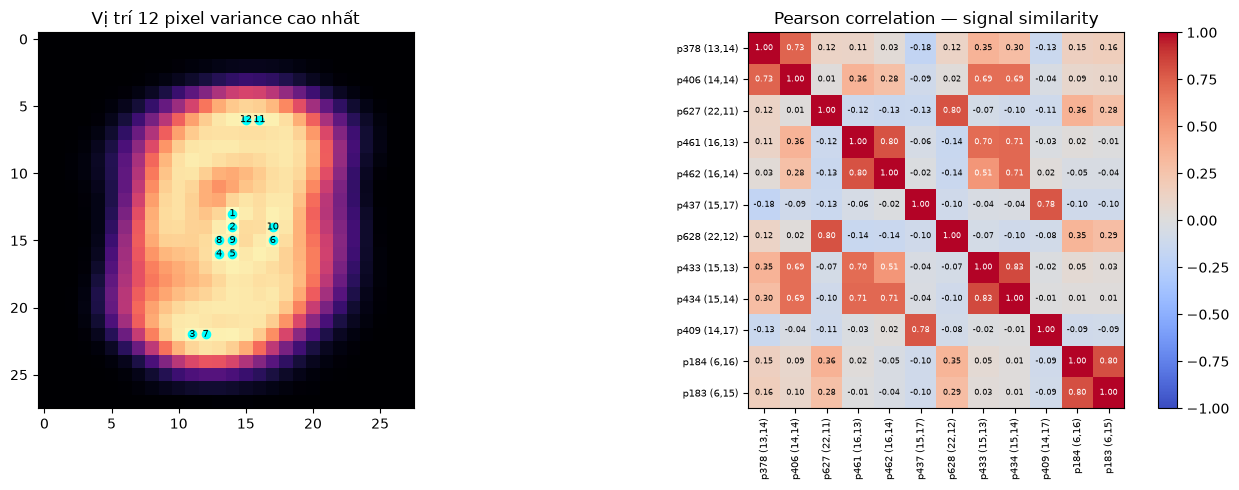

In [8]:
top = np.argsort(train_feature_var)[-12:][::-1]
coords = np.column_stack(np.unravel_index(top, (28, 28))); selected = flat_train[:, top]
corr = np.corrcoef(selected, rowvar=False)
labels12 = [f"p{i} ({r},{c})" for i, (r, c) in zip(top, coords)]
print("12 pixel có variance cao nhất:", labels12)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(X_train.var(axis=0), cmap="magma")
ax[0].scatter(coords[:, 1], coords[:, 0], c="cyan", s=35)
for k, (r, c) in enumerate(coords): ax[0].text(c, r, str(k+1), ha="center", va="center", fontsize=7)
ax[0].set_title("Vị trí 12 pixel variance cao nhất")
im = ax[1].imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax[1].set_xticks(range(12), labels12, rotation=90, fontsize=7); ax[1].set_yticks(range(12), labels12, fontsize=7)
for i in range(12):
    for j in range(12): ax[1].text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=6, color="white" if abs(corr[i,j]) > .5 else "black")
ax[1].set_title("Pearson correlation — signal similarity")
fig.colorbar(im, ax=ax[1]); plt.tight_layout(); plt.show()

### 4.1.1 VIF cho 12 pixel có variance cao nhất

**What:** Tính Variance Inflation Factor (VIF) cho 12 pixel đã chọn trên Train.

**Why:** VIF đánh giá mức một pixel có thể được giải thích tuyến tính bởi các pixel còn lại, phù hợp hơn correlation cặp để nhận diện multicollinearity.

**How:** hồi quy từng pixel theo 11 pixel còn lại; quy ước `VIF < 5` thường ổn, `5–10` đáng chú ý, `> 10` là mạnh.

p378 (13,14): VIF=2.73 — Ổn
p406 (14,14): VIF=5.50 — Đáng chú ý
p627 (22,11): VIF=2.94 — Ổn
p461 (16,13): VIF=4.51 — Ổn
p462 (16,14): VIF=4.34 — Ổn
p437 (15,17): VIF=2.67 — Ổn
p628 (22,12): VIF=2.91 — Ổn
p433 (15,13): VIF=5.06 — Đáng chú ý
p434 (15,14): VIF=7.16 — Đáng chú ý
p409 (14,17): VIF=2.61 — Ổn
p184 (6,16): VIF=3.05 — Ổn
p183 (6,15): VIF=2.89 — Ổn


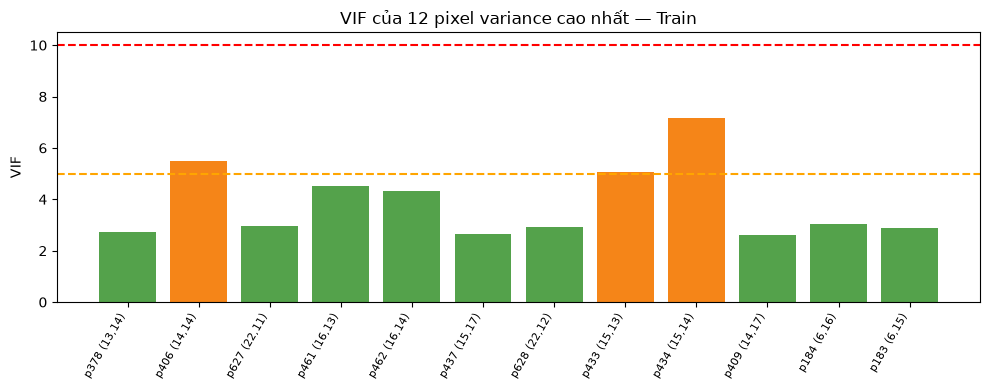

In [9]:
from sklearn.linear_model import LinearRegression
vif = []
for j in range(12):
    others = np.arange(12) != j
    r2 = LinearRegression().fit(selected[:, others], selected[:, j]).score(selected[:, others], selected[:, j])
    vif.append(np.inf if r2 >= 1 else 1 / (1 - r2))
vif = np.array(vif)
status = np.where(vif < 5, "Ổn", np.where(vif <= 10, "Đáng chú ý", "Mạnh"))
for name, value, level in zip(labels12, vif, status): print(f"{name}: VIF={value:.2f} — {level}")
colors = np.where(vif < 5, "#54A24B", np.where(vif <= 10, "#F58518", "#E45756"))
plt.figure(figsize=(10, 4)); plt.bar(range(12), vif, color=colors)
plt.axhline(5, ls="--", c="orange"); plt.axhline(10, ls="--", c="red")
plt.xticks(range(12), labels12, rotation=60, ha="right", fontsize=8)
plt.title("VIF của 12 pixel variance cao nhất — Train"); plt.ylabel("VIF"); plt.tight_layout(); plt.show()

### 4.1.2 Cặp correlation cao & khoảng cách không gian

**What:** Liệt kê các cặp pixel có `|r| >= 0.7` và khoảng cách Euclidean giữa tọa độ pixel.

**Why:** cặp tương quan cao nằm gần nhau thường phản ánh cùng nét chữ hoặc spatial similarity; cặp xa nhau có thể phản ánh pattern khác.

**How:** bỏ đường chéo, giữ mỗi cặp một lần, sắp theo `|r|` giảm dần và trực quan hóa correlation theo khoảng cách.

pixel_1 | pixel_2 | r | spatial_distance
p433 (15,13) | p434 (15,14) | 0.831 | 1.00
p184 (6,16) | p183 (6,15) | 0.805 | 1.00
p627 (22,11) | p628 (22,12) | 0.804 | 1.00
p461 (16,13) | p462 (16,14) | 0.800 | 1.00
p437 (15,17) | p409 (14,17) | 0.783 | 1.00
p378 (13,14) | p406 (14,14) | 0.728 | 1.00
p462 (16,14) | p434 (15,14) | 0.714 | 1.00
p461 (16,13) | p434 (15,14) | 0.714 | 1.41
p461 (16,13) | p433 (15,13) | 0.702 | 1.00


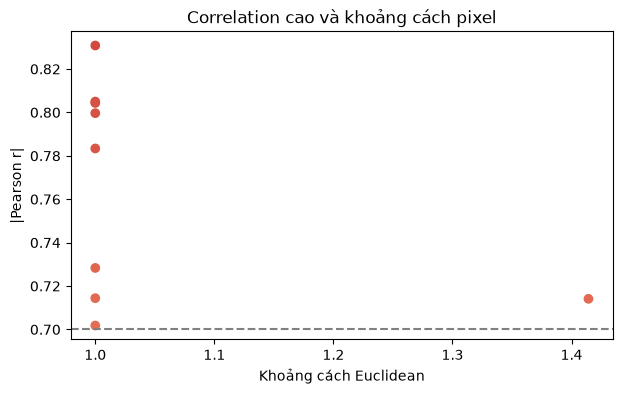

In [10]:
pairs = []
for i in range(12):
    for j in range(i + 1, 12):
        if abs(corr[i, j]) >= .7:
            distance = np.linalg.norm(coords[i] - coords[j])
            pairs.append((labels12[i], labels12[j], corr[i, j], distance))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print("pixel_1 | pixel_2 | r | spatial_distance")
for a, b, r, d in pairs: print(f"{a} | {b} | {r:.3f} | {d:.2f}")
plt.figure(figsize=(7, 4))
if pairs:
    plt.scatter([p[3] for p in pairs], [abs(p[2]) for p in pairs], c=[p[2] for p in pairs], cmap="coolwarm", vmin=-1, vmax=1)
else:
    plt.text(.5, .5, "Không có cặp |r| ≥ 0.7", ha="center", va="center"); plt.xlim(0,1); plt.ylim(0,1)
plt.axhline(.7, ls="--", c="gray"); plt.title("Correlation cao và khoảng cách pixel")
plt.xlabel("Khoảng cách Euclidean"); plt.ylabel("|Pearson r|"); plt.show()

## 4.2 Numerical vs Categorical — Mean Image & Pixel Statistics per Class

**What:** So sánh mean image và thống kê pixel giữa các nhãn.

**Why:** tìm hình dạng và độ sáng đặc trưng theo lớp.

**How:** tính trung bình ảnh, mean và standard deviation cho từng chữ số.

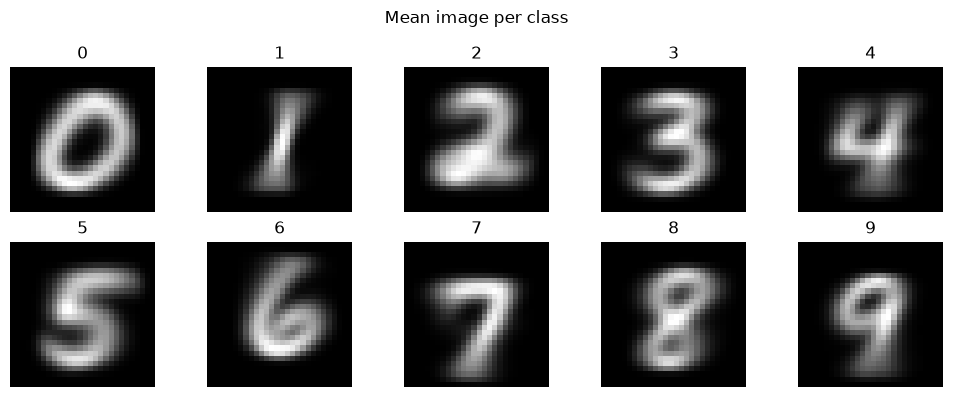

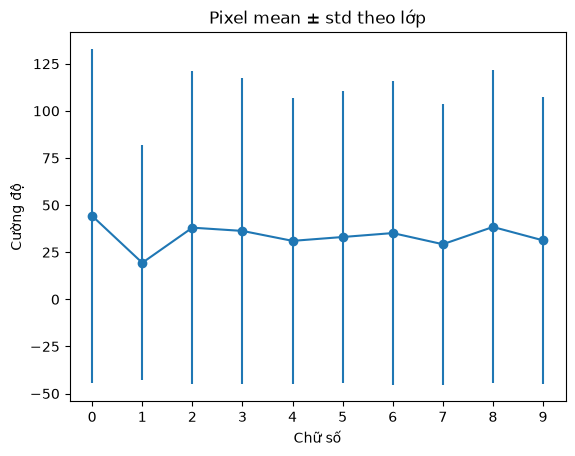

In [11]:
means = np.stack([X_train[y_train == d].mean(axis=0) for d in range(10)])
class_mean = np.array([X_train[y_train == d].mean() for d in range(10)]); class_std = np.array([X_train[y_train == d].std() for d in range(10)])
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for d, ax in enumerate(axes.flat): ax.imshow(means[d], cmap="gray"); ax.set_title(str(d)); ax.axis("off")
plt.suptitle("Mean image per class"); plt.tight_layout(); plt.show()
plt.errorbar(range(10), class_mean, yerr=class_std, fmt="o-")
plt.title("Pixel mean ± std theo lớp"); plt.xlabel("Chữ số"); plt.ylabel("Cường độ"); plt.xticks(range(10)); plt.show()

## 4.4 Patterns — Average Image, Variance Map & PCA/Class Overlap

**What:** Tìm pattern tổng thể và mức chồng lấn lớp.

**Why:** đánh giá khả năng phân tách trước khi mô hình hóa.

**How:** dùng average image, variance map và PCA 2D trên mẫu cố định 5.000 ảnh chỉ từ Train.

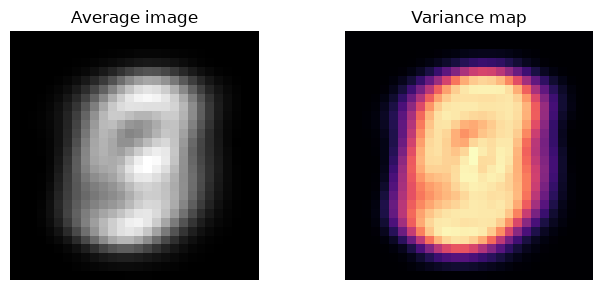

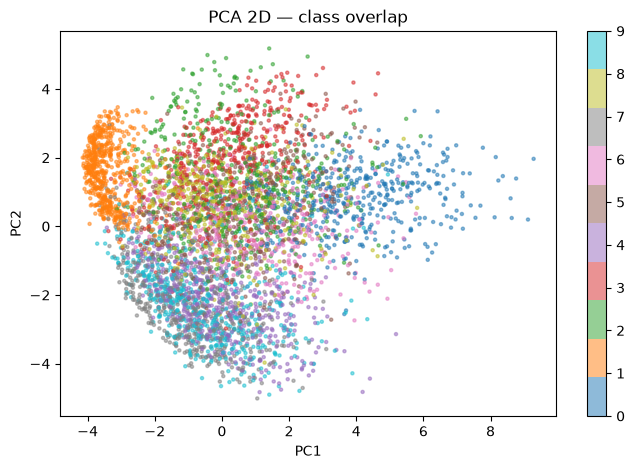

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(X_train.mean(axis=0), cmap="gray"); ax[0].set_title("Average image")
ax[1].imshow(X_train.var(axis=0), cmap="magma"); ax[1].set_title("Variance map")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
from sklearn.decomposition import PCA
rng = np.random.default_rng(42); idx = rng.choice(len(X_train), min(5000, len(X_train)), replace=False)
Z = PCA(n_components=2, random_state=42).fit_transform(flat_train[idx] / 255)
plt.figure(figsize=(8, 5)); sc = plt.scatter(Z[:, 0], Z[:, 1], c=y_train[idx], s=5, cmap="tab10", alpha=.5)
plt.title("PCA 2D — class overlap"); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.colorbar(sc, ticks=range(10)); plt.show()

# 5. Nhận Diện Dữ Liệu Thiếu, Trùng Lặp & Ngoại Lệ (Missing Data, Duplicate Data & Outliers)
## 5.1 Missing / Corrupted / Invalid Data

**What:** Đếm ảnh lỗi, shape sai, NaN và pixel ngoài miền hợp lệ.

**Why:** ngăn dữ liệu hỏng đi vào mô hình.

**How:** dùng lỗi đã ghi khi đọc và kiểm tra trực tiếp ma trận hợp lệ.

{'corrupted/shape': 0, 'NaN': 0, 'pixel < 0': 0, 'pixel > 255': 0}


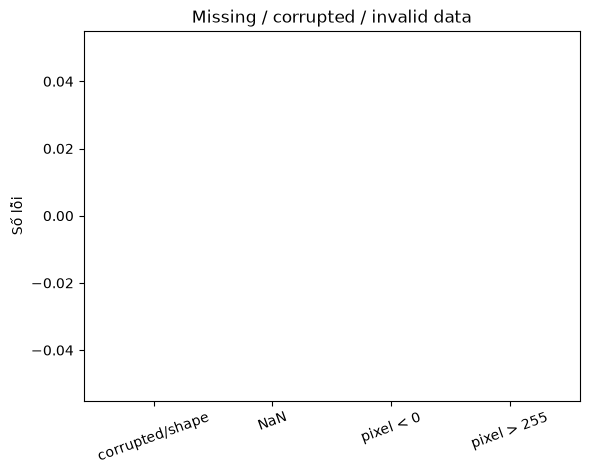

In [13]:
quality_errors = {"corrupted/shape": len(invalid), "NaN": int(np.isnan(flat_train).sum()),
                  "pixel < 0": int((flat_train < 0).sum()), "pixel > 255": int((flat_train > 255).sum())}
print(quality_errors)
plt.bar(quality_errors.keys(), quality_errors.values(), color="#E45756")
plt.title("Missing / corrupted / invalid data"); plt.ylabel("Số lỗi"); plt.xticks(rotation=20); plt.show()

## 5.2 Duplicate Images trong Train

**What:** Đếm ảnh trùng lặp nội bộ trong Train.

**Why:** ảnh trùng có thể làm lệch phân phối và tăng trọng số ngầm của một pattern.

**How:** tạo SHA-1 fingerprint từ bytes pixel Train. Train–Test leakage không được đánh giá trong EDA này để tránh đọc Test.

{'train_duplicate_extra_rows': 0}


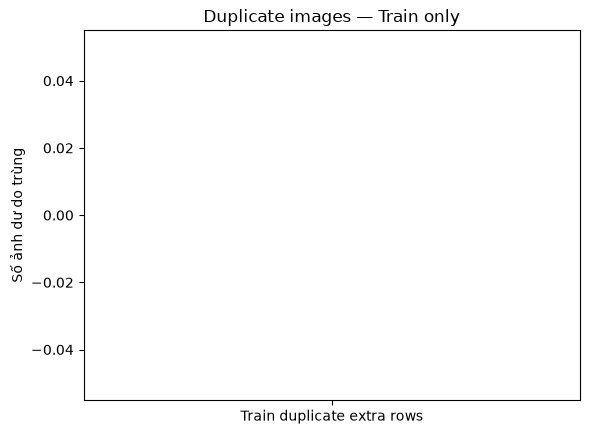

In [14]:
fingerprints = np.array([sha1(row.tobytes()).hexdigest() for row in flat_train])
fp_count = Counter(fingerprints); duplicate_rows = sum(n - 1 for n in fp_count.values() if n > 1)
print({"train_duplicate_extra_rows": duplicate_rows})
plt.bar(["Train duplicate extra rows"], [duplicate_rows], color="#F58518")
plt.title("Duplicate images — Train only"); plt.ylabel("Số ảnh dư do trùng"); plt.show()

## 5.3 Abnormal Images / Outliers

**What:** Tìm ảnh có mean hoặc standard deviation pixel bất thường.

**Why:** phát hiện ảnh trắng, đen hoặc nét quá khác biệt.

**How:** dùng robust z-score theo median/MAD và ngưỡng 5.

Outliers: 3 (0.01%)

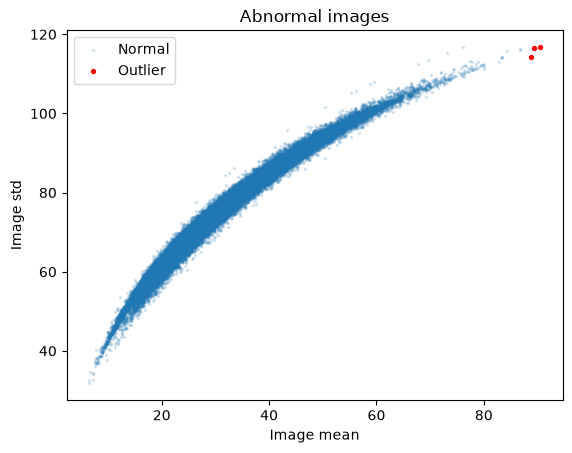

In [15]:
image_mean = flat_train.mean(axis=1); image_std = flat_train.std(axis=1)
def rz(v):
    med = np.median(v); mad = np.median(np.abs(v-med))
    return .6745 * np.abs(v-med) / (mad or 1)
outlier_score = np.maximum(rz(image_mean), rz(image_std)); outliers = outlier_score > 5
print(f"Outliers: {outliers.sum():,} ({outliers.mean():.2%})")
plt.scatter(image_mean[~outliers], image_std[~outliers], s=2, alpha=.15, label="Normal")
plt.scatter(image_mean[outliers], image_std[outliers], s=8, c="red", label="Outlier")
plt.title("Abnormal images"); plt.xlabel("Image mean"); plt.ylabel("Image std"); plt.legend(); plt.show()

# 6. Đánh Giá Chất Lượng Dữ Liệu & Trực Quan Hóa (Data Quality & Data Visualization)
## 6.1 Tổng hợp visualization

**What:** Gom bốn tín hiệu EDA quan trọng vào một dashboard.

**Why:** giúp đọc nhanh quy mô, cân bằng lớp, cường độ và outlier.

**How:** tái sử dụng các thống kê đã tính, không quét dữ liệu lần nữa.

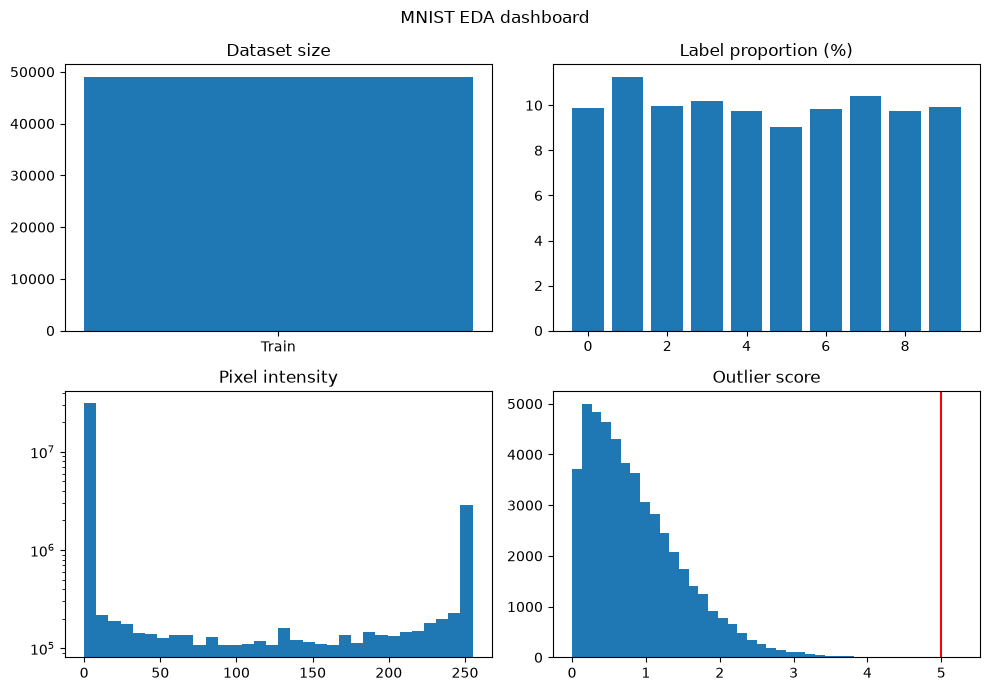

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0,0].bar(counts.keys(), counts.values()); ax[0,0].set_title("Dataset size")
ax[0,1].bar(range(10), label_pct); ax[0,1].set_title("Label proportion (%)")
ax[1,0].hist(flat_train.ravel(), bins=32, range=(0,255), log=True); ax[1,0].set_title("Pixel intensity")
ax[1,1].hist(outlier_score, bins=40); ax[1,1].axvline(5, c="red"); ax[1,1].set_title("Outlier score")
plt.suptitle("MNIST EDA dashboard"); plt.tight_layout(); plt.show()

## 6.2 Data Quality Assessment

**What:** Chấm ba chỉ báo trên Train: ảnh hợp lệ, cân bằng lớp và không outlier.

**Why:** kết luận dữ liệu Train có sẵn sàng cho feature engineering hay không mà không nhìn vào Test.

**How:** chuẩn hóa mỗi chỉ báo về 0–100; leakage không nằm trong điểm vì EDA không đọc Test.

{'Valid images': 100.0, 'Class balance': np.float64(80.14), 'Non-outlier': np.float64(99.99)}


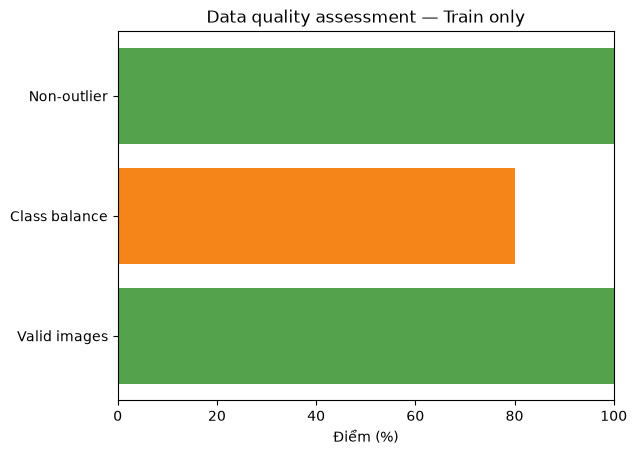

In [17]:
scores = {"Valid images": 100 * len(X_train)/(len(X_train)+len(invalid)),
          "Class balance": 100 * label_count.min()/label_count.max(),
          "Non-outlier": 100 * (1-outliers.mean())}
print({k: round(v, 2) for k, v in scores.items()})
colors = ["#54A24B" if v >= 95 else "#F58518" if v >= 80 else "#E45756" for v in scores.values()]
plt.barh(list(scores), list(scores.values()), color=colors); plt.xlim(0,100)
plt.title("Data quality assessment — Train only"); plt.xlabel("Điểm (%)"); plt.show()